In [1]:
#Project Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
"""Q1 – Libraries Required:

Pandas – For data manipulation and analysis using DataFrames
Datetime – For parsing and working with date/time data
Matplotlib – For creating static, customizable visualizations
Seaborn – For high-level, aesthetically pleasing statistical plots"""

'Q1 – Libraries Required:\n\nPandas – For data manipulation and analysis using DataFrames\nDatetime – For parsing and working with date/time data\nMatplotlib – For creating static, customizable visualizations\nSeaborn – For high-level, aesthetically pleasing statistical plots'

In [4]:
df= pd.read_csv("imdb_movies.csv")

In [5]:
df.shape

(10178, 12)

In [6]:
""" Q2 - Shape of the dataset

Each row represents a movie
Each column describes a characteristic of that movie"""

' Q2 - Shape of the dataset\n\nEach row represents a movie\nEach column describes a characteristic of that movie'

In [7]:
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [8]:
#Data Overview and Basic Exploration

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [10]:
"""Q3 – .info() Insights:

Date column is stored as object dtype , needs to  be converted to datetime
Genre , Crew and Overview column has missing values, possibly due to data merging issues or data loss"""

'Q3 – .info() Insights:\n\nDate column is stored as object dtype , needs to  be converted to datetime\nGenre , Crew and Overview column has missing values, possibly due to data merging issues or data loss'

In [11]:
df.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [12]:
"""Q4 – .describe() Insights:

Rating Distribution: Mean ≈ Median - fairly balanced/symmetric distribution
Budget Distribution: Mean > Median - right-skewed ,few movies have very high budgets
Revenue Distribution: Strong right skew - few movies earn extremely high revenue"""

'Q4 – .describe() Insights:\n\nRating Distribution: Mean ≈ Median - fairly balanced/symmetric distribution\nBudget Distribution: Mean > Median - right-skewed ,few movies have very high budgets\nRevenue Distribution: Strong right skew - few movies earn extremely high revenue'

In [13]:
#Data Cleaning

In [14]:
df["genre"].isnull().sum()

np.int64(85)

In [15]:
df["crew"].isnull().sum()


np.int64(56)

In [16]:
df[df['genre'].isnull()].head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
305,Housewife Sex Slaves: Hatano Yui,01/09/2015,0.0,NaN,We don't have an overview translated in Englis...,"Yui Hatano,",人妻性奴隷 波多野結衣,Released,Japanese,167540000.0,1.752700e+08,JP
1174,Beauty Rope Cosmetology,12/02/1983,10.0,NaN,Miki is the daughter of an affluent family. Sh...,"Miki Takakura, Miki, Maya Ito, Rena, Ren Osugi...",団鬼六 美女縄化粧,Released,Japanese,201940000.0,3.815731e+07,JP
1561,Reclaim,07/29/2022,20.0,NaN,She is a good woman living a fulfilling life. ...,NaN,Reclaim,Released,Chinese,12001040.0,3.813901e+07,US
1762,Ancient Chinese Whorehouse,09/15/1994,50.0,NaN,Madam Five and carpenter Kong work together ma...,"Kent Cheng, Kong, Yvonne Yung Hung, Miss Ng, S...",青樓十二房,Released,Cantonese,163600000.0,8.126672e+08,HK
1776,Porno document: Toruko tokkyû bin,02/26/1982,100.0,NaN,Pinku from 1982.,"Jun Miho, , Rumi Kagawa, , Miyuki Oka, , Kayok...",ポルノドキュメント トルコ特急便,Released,Japanese,201000000.0,1.569324e+09,JP


In [17]:
print (df.shape)
df= df.dropna(subset="genre")
print(df.shape)

(10178, 12)
(10093, 12)


In [18]:
"""Q5 – Missing Values:

Columns with missing values: Genre, Crew, and Overview
It can be due to less popularity of the movie or data loss.
Missing genre values can be dropped because it is used for further analysis"""

'Q5 – Missing Values:\n\nColumns with missing values: Genre, Crew, and Overview\nIt can be due to less popularity of the movie or data loss.\nMissing genre values can be dropped because it is used for further analysis'

In [19]:
df['date_x']= pd.to_datetime(df['date_x'])

In [20]:
df['date_x'].dtype

dtype('<M8[ns]')

In [21]:
df.head(5)

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [22]:
df["score"].unique()

array([ 73.,  78.,  76.,  70.,  61.,  66.,  80.,  83.,  59.,  58.,  55.,
        65.,  72.,  62.,  64.,  57.,  69.,  74.,  53.,  71.,  63.,  60.,
        54.,  52.,  81.,  68.,  79.,  67.,  47.,  82.,  43.,  56.,  75.,
         0.,  77.,  84.,  49.,  46.,  30., 100.,  48.,  86.,  85.,  50.,
        87.,  37.,  34.,  20.,  38.,  35.,  36.,  44.,  51.,  45.,  40.,
        27.,  22.,  90.,  42.,  10.,  25.,  92.,  33.,  28.,  29.,  41.,
        15.,  39.,  32.,  16.,  17.,  23.,  91.,  93.,  13.,  26.,  98.,
        18.])

In [23]:
df["score"] = df["score"]/10

In [24]:
"""Q6 – Data Type Conversions:

Date needs to be converted from object type to date-time 
Rescale Score to a 0–10 scale for standardization"""

'Q6 – Data Type Conversions:\n\nDate needs to be converted from object type to date-time \nRescale Score to a 0–10 scale for standardization'

In [25]:
#Univariate Analysis

In [26]:
df.columns

Index(['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country'],
      dtype='object')

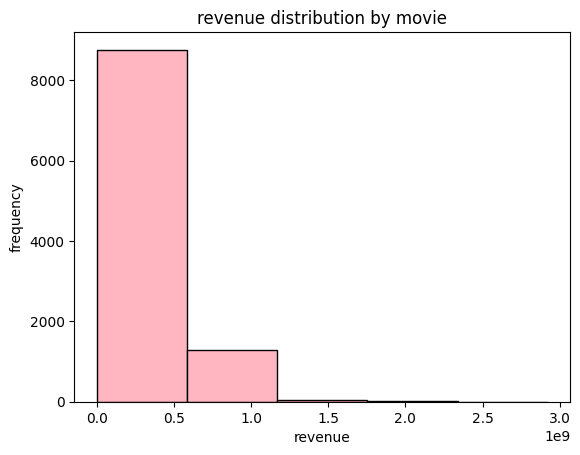

In [27]:
plt.hist(df['revenue'],bins=5,color="lightpink",edgecolor="black")
#plt.figure(figsize=(12,4))
plt.xlabel("revenue")
plt.ylabel("frequency")
plt.title("revenue distribution by movie")
plt.show()

In [28]:
"""Q7 – Distribution of Movie Runtime :

The dataset does not contain a runtime column , alternative columns can be analyzed such as Score & Revenue"""

'Q7 – Distribution of Movie Runtime :\n\nThe dataset does not contain a runtime column , alternative columns can be analyzed such as Score & Revenue'

In [29]:
df["genre"] = df["genre"].str.replace("\xa0", " ", regex=False)
df["genre"] = df["genre"].str.split(",")
df["genre"] = df["genre"].apply(lambda x: [i.strip() for i in x])
df = df.explode("genre")
df.head()
df['genre'].unique()

array(['Drama', 'Action', 'Science Fiction', 'Adventure', 'Animation',
       'Family', 'Fantasy', 'Comedy', 'Thriller', 'Crime', 'Horror',
       'Mystery', 'History', 'War', 'Documentary', 'Romance', 'Music',
       'Western', 'TV Movie'], dtype=object)

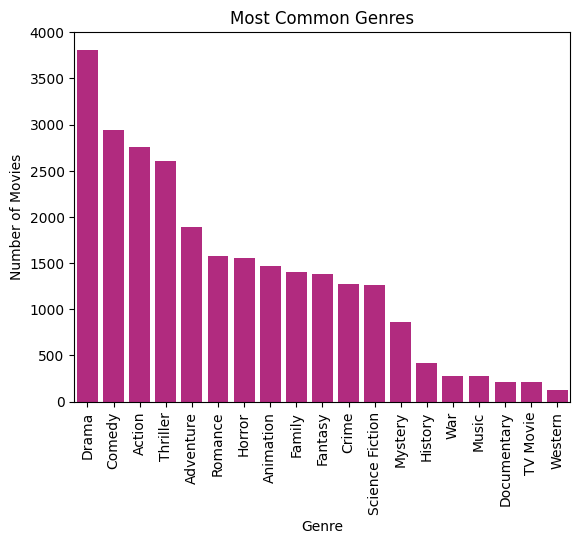

In [30]:
common_genre= df['genre'].value_counts().sort_values(ascending=False).reset_index(name="count")
sns.barplot(data=common_genre, x="genre", y="count", color="mediumvioletred")
plt.xticks(rotation=90)
plt.title("Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()


In [31]:
"""Q8 – Most Common Genres:

Most common genre: Drama 
Least common genre: Western """

'Q8 – Most Common Genres:\n\nMost common genre: Drama \nLeast common genre: Western '

In [32]:
#Bivariate Analysis

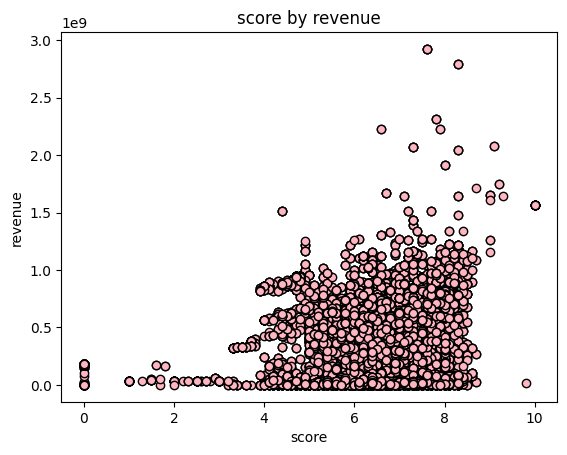

In [33]:
plt.scatter(df['score'],df['revenue'],c="lightpink",edgecolor="black")
plt.xlabel("score")
plt.ylabel("revenue")
plt.title("score by revenue")
plt.show()


In [34]:
df["score"].corr(df["revenue"])

np.float64(0.10364463776992934)

In [35]:
"""Q8 – Relationship btw Movie Runtime and ratings:

The dataset does not contain a runtime column hence the relationship can not be evaluated, instead some other column can be used 
(as mentioned above) """

'Q8 – Relationship btw Movie Runtime and ratings:\n\nThe dataset does not contain a runtime column hence the relationship can not be evaluated, instead some other column can be used \n(as mentioned above) '

C:\Users\hp\AppData\Local\Temp\ipykernel_41128\4249614555.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["genre"],y=df["score"],palette="RdPu")


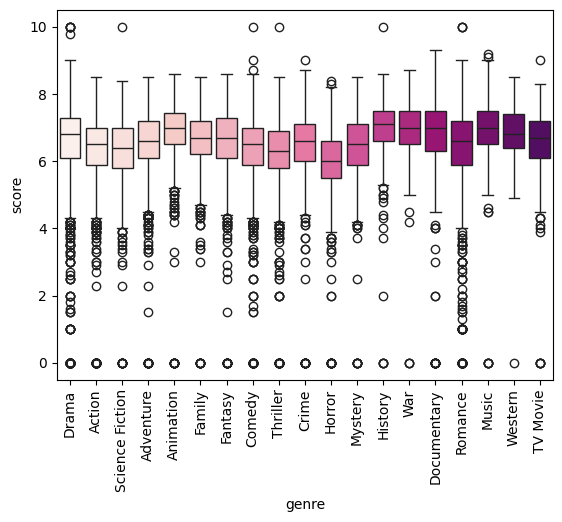

In [36]:
sns.boxplot(x=df["genre"],y=df["score"],palette="RdPu")
plt.xticks(rotation= 90)
plt.show()

In [37]:
"""Q9 - Variation of ratings by Genre"""

'Q9 - Variation of ratings by Genre'

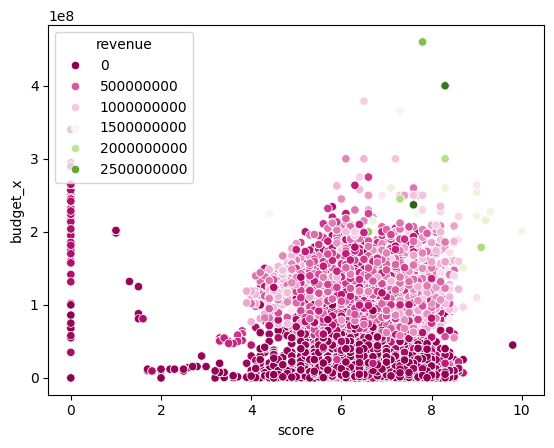

In [38]:
sns.scatterplot(x=df['score'],y=df['budget_x'],hue=df['revenue'],palette='PiYG')
plt.show()


In [39]:
df[["score", "budget_x", "revenue"]].corr()

,score,budget_x,revenue
score,1.000000,-0.156323,0.103645
budget_x,-0.156323,1.000000,0.697361
revenue,0.103645,0.697361,1.000000


In [40]:
"""Q11 – Score vs Budget vs Revenue:

Observation: Movies with higher scores (7–9) tend to have higher budgets and generate more revenue
Positive correlation between score, budget, and revenue"""

'Q11 – Score vs Budget vs Revenue:\n\nObservation: Movies with higher scores (7–9) tend to have higher budgets and generate more revenue\nPositive correlation between score, budget, and revenue'

In [41]:
#Genre-Specific Analysis

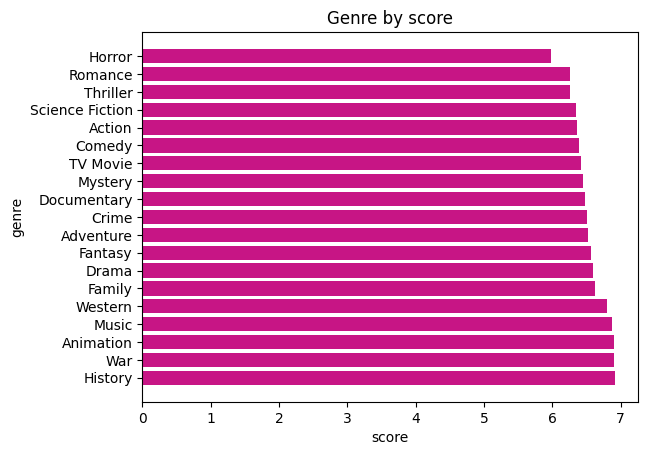

In [42]:
genre_rating=df.groupby("genre")["score"].mean().sort_values(ascending=False)
plt.barh(genre_rating.index,genre_rating.values,color="mediumvioletred")
plt.xlabel("score")
plt.ylabel("genre")
plt.title("Genre by score")
plt.show()

In [43]:
"""Q12 – Highest Average Rating by Genre:

Observation: History has the highest average score (~7.0), while Horror has the lowest (~5.9)"""

'Q12 – Highest Average Rating by Genre:\n\nObservation: History has the highest average score (~7.0), while Horror has the lowest (~5.9)'

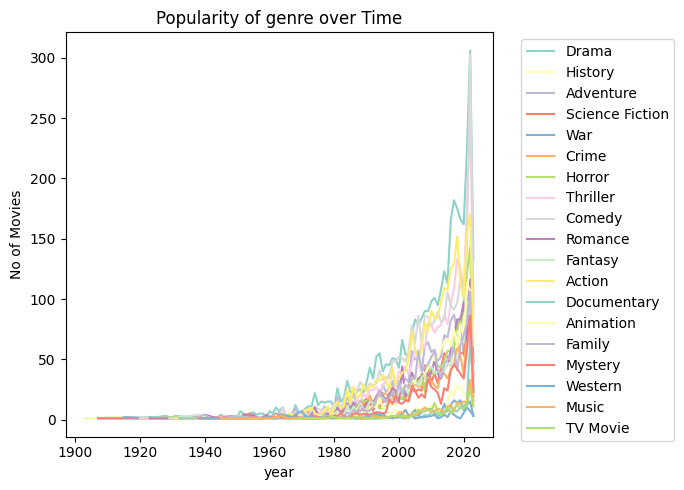

In [63]:
df["year"] = df["date_x"].dt.year
genre_trend = df[df['status']=="released"].groupby(["year", "genre"]).size().reset_index(name="count")
plt.figure(figsize=(7,5))
sns.lineplot(data=genre_trend, x="year", y="count", hue="genre", palette="Set3")
plt.title("Popularity of genre over Time")
plt.ylabel("No of Movies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [45]:
"""Q13 – Popularity of Genres Over Time:

Observation: Movie production across all genres increased post-1980, peaking around 2020 with Drama leading in volume."""

'Q13 – Popularity of Genres Over Time:\n\nObservation: Movie production across all genres increased post-1980, peaking around 2020 with Drama leading in volume.'

In [46]:
# Year and Trend Analysis

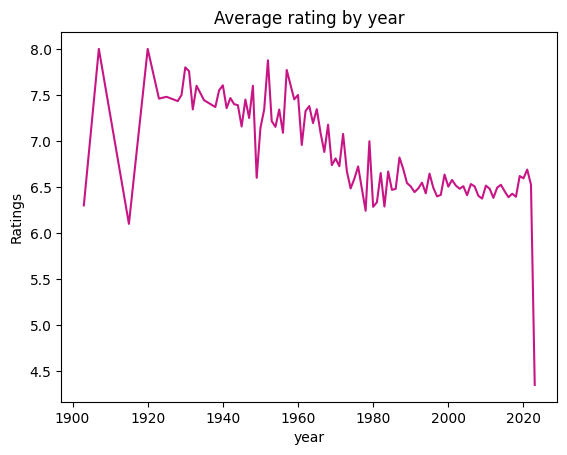

In [47]:
rating_trend=df.groupby("year")["score"].mean()
sns.lineplot(x=rating_trend.index, y=rating_trend.values, color="mediumvioletred")
plt.title("Average rating by year")
plt.ylabel("Ratings")
plt.show()

In [48]:
"""Q14 – Average Movie Rating Over the Years:

Average ratings have declined over the years"""

'Q14 – Average Movie Rating Over the Years:\n\nAverage ratings have declined over the years'

In [49]:
df["status"].unique()


array([' Released', ' Post Production', ' In Production'], dtype=object)

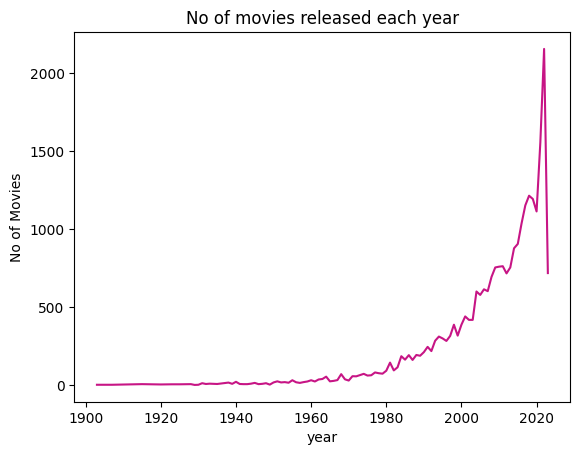

In [50]:
df["status"] = df["status"].str.strip().str.lower()
movie_release_trend= df[df['status']=="released"].groupby("year").size()
sns.lineplot(x=movie_release_trend.index, y=movie_release_trend.values, color="mediumvioletred")
plt.ylabel("No of Movies")
plt.title("No of movies released each year")
plt.show()

In [51]:
"""Q15 – Number of Movies Released Each Year:

Observation: Movie releases has grown over the years."""

'Q15 – Number of Movies Released Each Year:\n\nObservation: Movie releases has grown over the years.'

In [52]:
#Multivariate Analysis

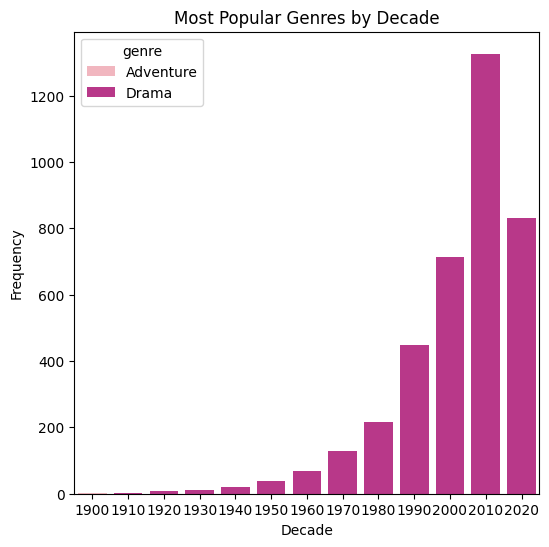

In [53]:
df['decade']=(df['year']//10)*10
decade_wise=df.groupby(["decade","genre"]).size().reset_index(name="count")
popular_genre=decade_wise.sort_values(['decade','count'], ascending=[True,False]).groupby("decade").head(1)

plt.figure(figsize=(6,6))
sns.barplot(data=popular_genre, x="decade", y="count", hue="genre", palette="RdPu")
plt.title("Most Popular Genres by Decade")
plt.xlabel("Decade")
plt.ylabel("Frequency")
plt.show()


In [54]:
"""Q16 – Most Popular Genres by Decade: Drama"""

'Q16 – Most Popular Genres by Decade: Drama'

C:\Users\hp\AppData\Local\Temp\ipykernel_41128\4003413236.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table=df.pivot_table(


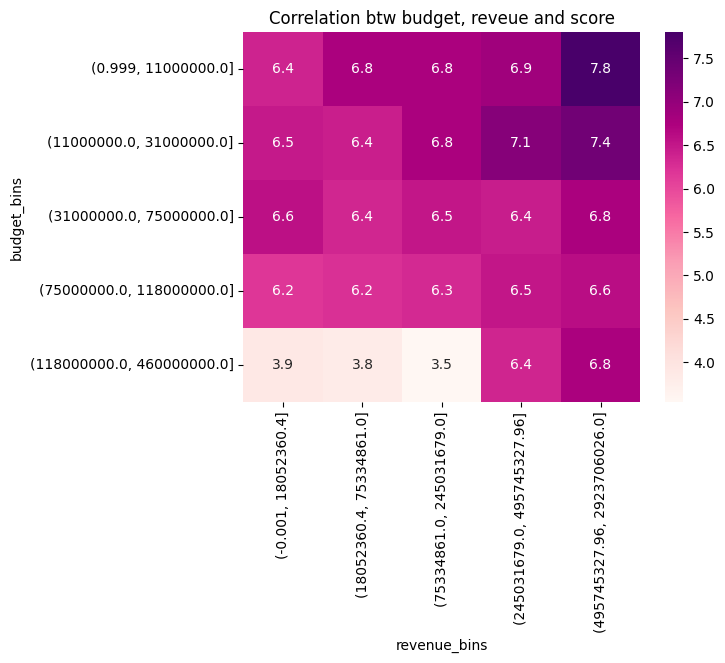

In [55]:
df['budget_bins']=pd.qcut(df['budget_x'],5)
df['revenue_bins']=pd.qcut(df['revenue'],5)

table=df.pivot_table(
    values="score",
    index="budget_bins",
    columns="revenue_bins",
    aggfunc="mean")

sns.heatmap(table,annot = True,cmap="RdPu")
plt.title("Correlation btw budget, reveue and score")
plt.show()


In [56]:
"""Q17 – Heatmap: Budget, Revenue & Score:

Observation: Movies with the highest revenue and moderate budgets achieve the best average scores, 
while very high-budget but low-revenue films score the lowest"""

'Q17 – Heatmap: Budget, Revenue & Score:\n\nObservation: Movies with the highest revenue and moderate budgets achieve the best average scores, \nwhile very high-budget but low-revenue films score the lowest'

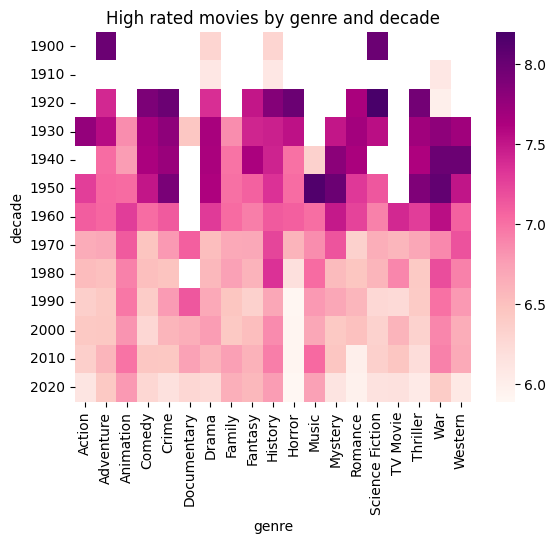

In [57]:
gb=df.groupby(["decade","genre"]).agg({'score':'mean'})
table=df.pivot_table(
    values="score",
    index="decade",
    columns="genre",
    aggfunc="mean"
)
sns.heatmap(table, cmap="RdPu")
plt.title("High rated movies by genre and decade")
plt.show()

In [58]:
"""Q18 – High Rated Movies by Genre & Decade:

Observation: Earlier decades (1920s–1950s) show higher ratings (~7.5–8.0) across most genres, 
while post-2000 movies show a uniform decline in average scores across all genres"""

'Q18 – High Rated Movies by Genre & Decade:\n\nObservation: Earlier decades (1920s–1950s) show higher ratings (~7.5–8.0) across most genres, \nwhile post-2000 movies show a uniform decline in average scores across all genres'

In [59]:
#Insights and Summary

In [60]:
""" Q19 – Three Major Insights:

Insight 1: Drama dominates the film industry in volume, but History and War genres consistently achieve the highest average ratings
Insight 2: Movie production has grown exponentially since the 1980s, but average ratings have declined over time — more quantity, less quality
Insight 3: Higher revenue strongly correlates with better scores, but extremely high budgets don't always guarantee high revenue or ratings """

" Q19 – Three Major Insights:\n\nInsight 1: Drama dominates the film industry in volume, but History and War genres consistently achieve the highest average ratings\nInsight 2: Movie production has grown exponentially since the 1980s, but average ratings have declined over time — more quantity, less quality\nInsight 3: Higher revenue strongly correlates with better scores, but extremely high budgets don't always guarantee high revenue or ratings "

In [61]:
"""Q20 – Additional Questions to Explore:

Country-wise most popular genre or movie sales
Post-production vs release — when do movies generate more sales?
Language-wise revenue — which language movies generate the most revenue?"""

'Q20 – Additional Questions to Explore:\n\nCountry-wise most popular genre or movie sales\nPost-production vs release — when do movies generate more sales?\nLanguage-wise revenue — which language movies generate the most revenue?'